# Study Comparison by Map Type

Issue-by-issue comparison across all four conditions collected so far:

- **Baseline** — no map, no tools (Study 1, `none`)
- **Map as context** — wholesale map injected into the system prompt (Study 1)
- **Map as tool (free)** — model may voluntarily call a lookup tool (Study 2)
- **Map as tool (required)** — submit is gated on calling the tool at least once (Study 3)

Organised by **map type** (structural / frequency / co-change / all tools combined) rather than by study, so the three delivery mechanisms for the same underlying signal sit side by side. Each issue is shown with its original title and body, then a pooled bar chart (mean across the 4 models with complete coverage) followed by a per-model breakdown, for precision/recall/F1.

In [1]:
import json
import os
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.join(os.path.dirname(os.getcwd()), '') if 'notebooks' in os.getcwd() else os.getcwd()
SEL_CSV = os.path.join(ROOT, 'data', 'issue_selection_final.csv')

# Which results/ tree each condition's files live under.
CONDITION_ROOT = {
    'none': 'study_1/results', 'ast_compact': 'study_1/results',
    'cochange': 'study_1/results', 'freq': 'study_1/results',
    'structural': 'study_2/results', 'temporal_frequency': 'study_2/results',
    'temporal_cochange': 'study_2/results', 'all_tools': 'study_2/results',
    'structural_required': 'study_3/results', 'temporal_frequency_required': 'study_3/results',
    'temporal_cochange_required': 'study_3/results', 'all_tools_required': 'study_3/results',
}

# The 4 models with complete coverage across every condition above -- the
# only ones for which baseline/context/tool-free/tool-required are all
# directly comparable. See DEVLOG for how this was confirmed.
MODELS = [
    'mistral_ministral-3b-latest',
    'fireworks_ai_accounts_fireworks_models_gpt-oss-120b',
    'deepseek_deepseek-v4-flash',
    'deepinfra_nvidia_NVIDIA-Nemotron-3-Super-120B-A12B',
]
MODEL_LABELS = {
    'mistral_ministral-3b-latest': 'Ministral-3B',
    'fireworks_ai_accounts_fireworks_models_gpt-oss-120b': 'gpt-oss-120B',
    'deepseek_deepseek-v4-flash': 'DeepSeek-V4-Flash',
    'deepinfra_nvidia_NVIDIA-Nemotron-3-Super-120B-A12B': 'Nemotron-3-Super',
}

# Map type -> which condition fills each of the 4 delivery-mechanism roles.
# all_tools has no context-injection equivalent (Study 1 never wholesale-
# injected a combined map), so that group only has 3 bars, not 4.
MAP_TYPE_GROUPS = {
    'Structural':          {'baseline': 'none', 'context': 'ast_compact',
                             'tool_free': 'structural', 'tool_required': 'structural_required'},
    'Frequency':           {'baseline': 'none', 'context': 'freq',
                             'tool_free': 'temporal_frequency', 'tool_required': 'temporal_frequency_required'},
    'Co-change':           {'baseline': 'none', 'context': 'cochange',
                             'tool_free': 'temporal_cochange', 'tool_required': 'temporal_cochange_required'},
    'All tools (combined)': {'baseline': 'none',
                              'tool_free': 'all_tools', 'tool_required': 'all_tools_required'},
}

ROLE_ORDER = ['baseline', 'context', 'tool_free', 'tool_required']
ROLE_LABELS = {
    'baseline': 'Baseline',
    'context': 'Map as\ncontext',
    'tool_free': 'Map as tool\n(free)',
    'tool_required': 'Map as tool\n(required)',
}
# One hue, stepped by "intervention intensity" -- baseline is neutral grey,
# then progressively deeper teal as the map goes from absent to injected
# to available-on-request to mandatory.
ROLE_COLORS = {
    'baseline': '#9AA5A3',
    'context': '#7FB5AC',
    'tool_free': '#2E8B7C',
    'tool_required': '#123B36',
}

METRICS = ['precision', 'recall', 'f1']

sel_df = pd.read_csv(SEL_CSV)
print(f'{len(sel_df)} issues available')
sel_df[['repo', 'issue_idx', 'title']].head(3)


45 issues available


,repo,issue_idx,title
0,core,16,Mysensor HVAC frontend shows multiple values
1,core,20,Problems sending push message with HTML5 notify
2,fastapi,9,pass method return value as positional paramet...


In [2]:
def _load_all_trials():
    """Walk every (model, condition) pair once and build a long DataFrame of
    per-trial precision/recall/f1 plus the raw predicted/ground-truth file
    lists (scorable versions -- the same filtering that actually produced
    the scores), num_turns, and the real total_input_tokens/
    total_output_tokens billed for that trial (straight from each
    provider's own usage stats, not an estimate), keyed by
    repo/issue_idx/condition/model/rep. Reps are kept separate here and
    averaged later at plot time, so this cache only needs to be built
    once per kernel session."""
    rows = []
    for condition, results_subdir in CONDITION_ROOT.items():
        base = os.path.join(ROOT, results_subdir)
        for model in MODELS:
            model_dir = os.path.join(base, model)
            if not os.path.isdir(model_dir):
                continue
            for repo in os.listdir(model_dir):
                repo_dir = os.path.join(model_dir, repo)
                if not os.path.isdir(repo_dir):
                    continue
                for issue_idx in os.listdir(repo_dir):
                    cond_dir = os.path.join(repo_dir, issue_idx, condition)
                    if not os.path.isdir(cond_dir):
                        continue
                    for fname in os.listdir(cond_dir):
                        if not (fname.startswith('rep') and fname.endswith('.json')):
                            continue
                        with open(os.path.join(cond_dir, fname), encoding='utf-8') as f:
                            d = json.load(f)
                        scores = d.get('scores', {})
                        if scores.get('f1') is None:
                            continue
                        metrics = d.get('metrics', {})
                        rows.append({
                            'repo': repo,
                            'issue_idx': int(issue_idx),
                            'condition': condition,
                            'model': model,
                            'rep': d.get('rep'),
                            'precision': scores['precision'],
                            'recall': scores['recall'],
                            'f1': scores['f1'],
                            'predicted': d.get('final_files_predicted_scorable', []),
                            'ground_truth': d.get('ground_truth_scorable', []),
                            'num_turns': metrics.get('num_turns'),
                            'total_input_tokens': metrics.get('total_input_tokens'),
                            'total_output_tokens': metrics.get('total_output_tokens'),
                        })
    return pd.DataFrame(rows)


trials_df = _load_all_trials()
print(f'{len(trials_df)} trials loaded across {trials_df["condition"].nunique()} conditions '
      f'and {trials_df["model"].nunique()} models')
trials_df.groupby('condition').size()


6480 trials loaded across 12 conditions and 4 models


condition
all_tools                      540
all_tools_required             540
ast_compact                    540
cochange                       540
freq                           540
none                           540
structural                     540
structural_required            540
temporal_cochange              540
temporal_cochange_required     540
temporal_frequency             540
temporal_frequency_required    540
dtype: int64

In [3]:
def print_issue_header(repo, issue_idx):
    """Print the issue's original title and body, as pulled straight from
    issue_selection_final.csv (the source-of-truth dataset), so each
    issue's charts are read next to the actual problem being solved."""
    match = sel_df[(sel_df['repo'] == repo) & (sel_df['issue_idx'] == issue_idx)]
    if match.empty:
        print(f'No selection-csv entry for {repo}/{issue_idx}')
        return
    row = match.iloc[0]
    n_files = row['n_files']
    print('=' * 100)
    print(f'{repo}  ·  issue #{issue_idx}  ·  {n_files} ground-truth file(s)  ·  tier={row["tier"]}')
    print('-' * 100)
    print(textwrap.fill(str(row['title']), width=100))
    print('-' * 100)
    body = str(row['body']).strip()
    print(textwrap.fill(body, width=100) if body and body != 'nan' else '(no body)')
    print('=' * 100)


def _role_means(sub, condition):
    """Mean precision/recall/f1 for one condition within an already-filtered
    (repo, issue_idx) slice of trials_df. Returns None if no trials exist
    for this condition (e.g. an issue skipped on that model)."""
    rows = sub[sub['condition'] == condition]
    if rows.empty:
        return None
    return {m: rows[m].mean() for m in METRICS}


def plot_map_type_group(group_name, roles, repo, issue_idx):
    """One figure per map-type group for a single issue: pooled panel
    (mean across the 4 models) followed by one panel per model, each a
    grouped bar chart of precision/recall/F1 across whichever delivery
    mechanisms exist for this group."""
    issue_trials = trials_df[(trials_df['repo'] == repo) & (trials_df['issue_idx'] == issue_idx)]
    present_roles = [r for r in ROLE_ORDER if r in roles]

    panels = [('Pooled (mean of 4 models)', issue_trials)]
    for model in MODELS:
        panels.append((MODEL_LABELS[model], issue_trials[issue_trials['model'] == model]))

    fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 3.4), sharey=True)
    x = np.arange(len(METRICS))
    width = 0.8 / len(present_roles)

    for ax, (panel_label, sub) in zip(axes, panels):
        for i, role in enumerate(present_roles):
            means = _role_means(sub, roles[role])
            values = [means[m] if means else np.nan for m in METRICS]
            ax.bar(x + (i - (len(present_roles) - 1) / 2) * width, values, width,
                   color=ROLE_COLORS[role], label=ROLE_LABELS[role].replace('\n', ' '),
                   edgecolor='white', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(['Prec.', 'Rec.', 'F1'], fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_title(panel_label, fontsize=9.5, fontweight='bold')
        ax.yaxis.grid(True, alpha=0.35)
        ax.set_axisbelow(True)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)

    axes[0].set_ylabel('Score')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.14),
               ncol=len(present_roles), fontsize=9, frameon=False)
    fig.suptitle(f'{group_name}', fontsize=12, fontweight='bold', y=1.02, x=0.02, ha='left')
    plt.tight_layout()
    plt.show()


def _match_tag(predicted, gt_set):
    """Cheap one-glance verdict for a single trial's prediction, independent
    of the exact precision/recall numbers -- exact / partial overlap /
    complete miss / nothing predicted at all."""
    pred_set = set(predicted)
    if not pred_set:
        return 'empty '
    if pred_set == gt_set:
        return 'exact '
    if pred_set & gt_set:
        return 'partial'
    return 'miss   '


def print_predictions(group_name, roles, repo, issue_idx):
    """Ground truth plus every rep's predicted files, per model and per
    condition, for this map-type group -- printed directly under its chart
    (via show_issue) so the raw predictions behind each bar are readable
    in roughly the same spot as the bar itself."""
    issue_trials = trials_df[(trials_df['repo'] == repo) & (trials_df['issue_idx'] == issue_idx)]
    if issue_trials.empty:
        print(f'  {group_name}: no trials found for {repo}/{issue_idx}')
        return
    gt_set = set(issue_trials.iloc[0]['ground_truth'])
    present_roles = [r for r in ROLE_ORDER if r in roles]

    print(f'--- {group_name}: predictions  (ground truth: {sorted(gt_set)}) ---')
    for model in MODELS:
        model_sub = issue_trials[issue_trials['model'] == model]
        print(f'  {MODEL_LABELS[model]}')
        for role in present_roles:
            cond = roles[role]
            rows = model_sub[model_sub['condition'] == cond].sort_values('rep')
            label = ROLE_LABELS[role].replace('\n', ' ')
            if rows.empty:
                print(f'    {label:<20s}  (no trials)')
                continue
            parts = []
            for _, r in rows.iterrows():
                tag = _match_tag(r['predicted'], gt_set)
                files = ', '.join(r['predicted']) if r['predicted'] else '(none)'
                parts.append(f"r{r['rep']} [{tag}] {{{files}}}")
            print(f'    {label:<20s}  ' + '   '.join(parts))
    print()


def show_issue(repo, issue_idx):
    """Full deep-dive for one issue: header, then for each map-type group
    (structural / frequency / co-change / all tools) its bar chart
    immediately followed by the rep-by-rep predictions that produced it,
    and finally -- underneath every accuracy metric -- a second pass over
    the same groups showing turn count on its own (fixed 0-35 axis),
    then input and output tokens sharing one figure."""
    print_issue_header(repo, issue_idx)
    for group_name, roles in MAP_TYPE_GROUPS.items():
        plot_map_type_group(group_name, roles, repo, issue_idx)
        print_predictions(group_name, roles, repo, issue_idx)

    print()
    print('#' * 100)
    print('# Turn counts, input tokens, and output tokens (all map-type groups)')
    print('#' * 100)
    for group_name, roles in MAP_TYPE_GROUPS.items():
        plot_turns_group(group_name, roles, repo, issue_idx)
        plot_tokens_group(group_name, roles, repo, issue_idx)


In [4]:
def _turn_means(sub, condition):
    """Mean num_turns for one condition within an already-filtered
    (repo, issue_idx) slice of trials_df. None if no trials exist."""
    rows = sub[sub['condition'] == condition]
    if rows.empty or rows['num_turns'].isna().all():
        return None
    return rows['num_turns'].mean()


def _token_means(sub, condition, column):
    """Mean total_input_tokens or total_output_tokens for one condition
    within an already-filtered (repo, issue_idx) slice of trials_df --
    the real per-trial billed token count from each provider's own usage
    stats, not an estimate of map size. None if no trials exist."""
    rows = sub[sub['condition'] == condition]
    if rows.empty or rows[column].isna().all():
        return None
    return rows[column].mean()


def _bar_with_labels(ax, values, colors, fixed_ylim=None):
    """Bar chart with an integer value label above each bar -- useful
    whenever one bar can dwarf the others on the same axis, making the
    shorter bars' exact values unreadable without a printed number.
    fixed_ylim overrides the default "18% headroom above the tallest
    bar" scaling with an explicit (0, cap) -- used for turn count, where
    a fixed 35-turn cap (max_turns=30, plus up to 2 backstop turns and
    some headroom) makes bars comparable across panels/issues instead of
    each panel rescaling to its own tallest bar."""
    bars = ax.bar(range(len(values)), values, color=colors, edgecolor='white', linewidth=0.5)
    labels = ['' if (v is None or np.isnan(v)) else f'{v:.0f}' for v in values]
    ax.bar_label(bars, labels=labels, fontsize=7, padding=2)
    if fixed_ylim is not None:
        ax.set_ylim(0, fixed_ylim)
    else:
        finite = [v for v in values if v is not None and not np.isnan(v)]
        if finite:
            ax.set_ylim(0, max(finite) * 1.18)
    return bars


def _role_bar_row(ax, present_roles, values, col, ylabel, fixed_ylim=None):
    _bar_with_labels(ax, values, [ROLE_COLORS[r] for r in present_roles], fixed_ylim=fixed_ylim)
    ax.set_xticks(range(len(present_roles)))
    ax.set_xticklabels([ROLE_LABELS[r].replace('\n', ' ') for r in present_roles],
                        fontsize=8, rotation=25, ha='right')
    ax.set_ylabel(ylabel if col == 0 else '')
    ax.yaxis.grid(True, alpha=0.35)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)


TURN_AXIS_CAP = 35  # max_turns=30 + up to 2 backstop turns + headroom


def plot_turns_group(group_name, roles, repo, issue_idx):
    """One figure per map-type group: mean turn count per role, pooled
    then per model. Fixed y-axis (0-35) rather than autoscaled, so bar
    heights are directly comparable across panels and across issues
    instead of each panel rescaling to its own tallest bar."""
    issue_trials = trials_df[(trials_df['repo'] == repo) & (trials_df['issue_idx'] == issue_idx)]
    present_roles = [r for r in ROLE_ORDER if r in roles]

    panels = [('Pooled (mean of 4 models)', issue_trials)]
    for model in MODELS:
        panels.append((MODEL_LABELS[model], issue_trials[issue_trials['model'] == model]))

    fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 3.4), squeeze=False)

    for col, (panel_label, sub) in enumerate(panels):
        ax = axes[0][col]
        values = [_turn_means(sub, roles[role]) for role in present_roles]
        values = [v if v is not None else np.nan for v in values]
        _role_bar_row(ax, present_roles, values, col, 'Mean turns', fixed_ylim=TURN_AXIS_CAP)
        ax.set_title(panel_label, fontsize=9.5, fontweight='bold')

    fig.suptitle(f'{group_name} — Turn Count', fontsize=12, fontweight='bold',
                 y=1.02, x=0.02, ha='left')
    plt.tight_layout()
    plt.show()


def plot_tokens_group(group_name, roles, repo, issue_idx):
    """One figure per map-type group, input tokens (row 0) and output
    tokens (row 1) sharing a single header -- both are real per-trial
    billed token counts from each provider's own usage stats, not an
    estimate of map size, kept together since they're the two halves of
    the same "what did this trial actually cost" question."""
    issue_trials = trials_df[(trials_df['repo'] == repo) & (trials_df['issue_idx'] == issue_idx)]
    present_roles = [r for r in ROLE_ORDER if r in roles]

    panels = [('Pooled (mean of 4 models)', issue_trials)]
    for model in MODELS:
        panels.append((MODEL_LABELS[model], issue_trials[issue_trials['model'] == model]))

    fig, axes = plt.subplots(2, len(panels), figsize=(3.1 * len(panels), 6.0), squeeze=False)

    for col, (panel_label, sub) in enumerate(panels):
        ax = axes[0][col]
        values = [_token_means(sub, roles[role], 'total_input_tokens') for role in present_roles]
        values = [v if v is not None else np.nan for v in values]
        _role_bar_row(ax, present_roles, values, col, 'Mean input tokens')
        ax.set_title(panel_label, fontsize=9.5, fontweight='bold')

        ax = axes[1][col]
        values = [_token_means(sub, roles[role], 'total_output_tokens') for role in present_roles]
        values = [v if v is not None else np.nan for v in values]
        _role_bar_row(ax, present_roles, values, col, 'Mean output tokens')

    fig.suptitle(f'{group_name} — Input & Output Tokens', fontsize=12, fontweight='bold',
                 y=1.01, x=0.02, ha='left')
    plt.tight_layout()
    plt.show()


## Trajectory plots

A different kind of chart: instead of summarizing outcomes, this traces *how* each trial got
there. One line per trial: x-axis is cumulative input tokens (per-turn `prompt_tokens` from the
raw API log, which already reflects the full growing context, not an estimate), y-axis is turn
number. Each node is a small pie chart showing which tool(s) were called that turn; a rejected
`submit_answer` gets a small `!` marker. Line segments are colored on a fixed red-green scale by
directory-tree distance from whatever was touched that turn to the nearest ground-truth file (0 =
green = the correct file itself, 5+ = red). The final node overrides to the same colormap but
driven by the trial's F1 instead of distance. Faceted into a (model x role) grid, 3 rep-lines
overlaid per panel, since a single issue for one map-type group can have up to 48 trials -- too
many for one axes.

Not part of `show_issue()`'s automatic output -- call `plot_trajectories(repo, issue_idx,
group_name)` directly for whichever issue/map-type you want to inspect closely. Optional toggles:

- `align_y_per_model=True` -- share one token-axis range across a model's 4 role panels (scaled
  to that row's own max), so a role with naturally lower token usage doesn't look like it's
  hitting the ceiling just because its own panel auto-scaled tightly. Rows are not aligned to
  each other, since token volume varies hugely by model.
- `fixed_x_axis=True` -- cap every panel's turn axis at 32, identically across the whole grid.
- `show_nodes=False` -- hide the intermediate per-turn tool-call nodes, leaving just the
  distance-colored lines. The final (F1-colored) node and any "!" rejection marker still show.

In [5]:
DISTANCE_CAP = 5          # 5+ directory steps away renders as fully red
DISTANCE_CMAP = plt.cm.RdYlGn_r   # reversed: 0 -> green, 1 -> red
F1_CMAP = plt.cm.RdYlGn            # not reversed: 0 -> red, 1 -> green

# Categorical node-fill palette: bright, maximally distinct hues rather
# than same-family shades (an earlier same-family attempt -- blue-greys
# for exploration, purples for lookup -- looked tidy but adjacent shades
# were too close to tell apart at pie-slice size). Avoids pure red/green,
# since those are already load-bearing for the distance/F1 colormap used
# elsewhere on this same chart.
TOOL_CATEGORY_COLORS = {
    'list_files': '#2196F3',
    'read_file': '#00BCD4',
    'search': '#3F51B5',
    'lookup_structure': '#E91E8C',
    'lookup_frequency': '#9C27B0',
    'lookup_cochange': '#6A1B9A',
    'submit_answer': '#FF9800',
}
EXPLORATION_TOOLS = {'list_files', 'read_file', 'search'}
LOOKUP_TOOLS = {'lookup_structure', 'lookup_frequency', 'lookup_cochange'}


def dir_distance(a, b):
    """Directory-tree steps between two file paths -- 0 if same directory,
    1 for adjacent directories, etc. Empty-string paths (e.g. a whole-repo
    search) fall out naturally: their "directory" is the repo root, so the
    distance becomes just the depth of the other file's directory."""
    a_dir = a.split('/')[:-1]
    b_dir = b.split('/')[:-1]
    common = 0
    for x, y in zip(a_dir, b_dir):
        if x == y:
            common += 1
        else:
            break
    return (len(a_dir) - common) + (len(b_dir) - common)


def min_distance_to_gt(path, gt_files):
    """Minimum dir_distance from path to any ground-truth file. None if
    there are no ground-truth files to compare against (shouldn't happen
    in practice) or path is falsy."""
    if not gt_files or not path:
        return None
    if path in gt_files:
        return 0
    return min(dir_distance(path, gt) for gt in gt_files)


def distance_to_color(distance):
    """None (no info this turn) renders as the worst case, red -- per the
    "empty is automatically red" rule."""
    if distance is None:
        return DISTANCE_CMAP(1.0)
    x = min(distance, DISTANCE_CAP) / DISTANCE_CAP
    return DISTANCE_CMAP(x)


def f1_to_color(f1):
    if f1 is None:
        return F1_CMAP(0.0)
    return F1_CMAP(max(0.0, min(1.0, f1)))


In [6]:
import matplotlib.path as mpath

NODE_SIZE = 16
FINAL_NODE_SIZE = 55


def _pie_wedge_marker(start_frac, end_frac):
    """Custom scatter marker Path: a pie wedge from start_frac to end_frac
    (0-1 around a full circle). A full 0->1 wedge is a full circle."""
    n = max(2, int(48 * (end_frac - start_frac)))
    angles = np.linspace(start_frac, end_frac, n) * 2 * np.pi
    xs = np.concatenate([[0.0], np.cos(angles), [0.0]])
    ys = np.concatenate([[0.0], np.sin(angles), [0.0]])
    return mpath.Path(np.column_stack([xs, ys]))


def draw_node(ax, x, y, tool_counts, size=NODE_SIZE, edgecolor='white', zorder=3):
    """Draw one turn's node: a pie chart sized by tool_counts (dict of
    tool name -> number of times called that turn). A single-tool turn
    (the common case) draws as a plain full circle. Kept small (see
    NODE_SIZE) so the connecting line segments -- which carry the
    distance-to-ground-truth color -- stay visible between nodes rather
    than getting buried under them."""
    total = sum(tool_counts.values())
    if total == 0:
        ax.scatter([x], [y], marker='o', s=size, color='#999999',
                   edgecolors=edgecolor, linewidths=0.3, zorder=zorder)
        return
    start = 0.0
    for name, count in tool_counts.items():
        frac = count / total
        end = start + frac
        color = TOOL_CATEGORY_COLORS.get(name, '#999999')
        if end - start >= 0.999:
            ax.scatter([x], [y], marker='o', s=size, color=color,
                       edgecolors=edgecolor, linewidths=0.3, zorder=zorder)
        else:
            marker = _pie_wedge_marker(start, end)
            ax.scatter([x], [y], marker=marker, s=size, color=color,
                       edgecolors=edgecolor, linewidths=0.2, zorder=zorder)
        start = end


def draw_final_node(ax, x, y, f1, zorder=4):
    """The trial's last node overrides tool-type coloring: same red-green
    colormap as the line segments, driven by F1 instead of distance.
    Still noticeably larger than a regular node (see FINAL_NODE_SIZE) so
    it reads as the outcome marker, but scaled down from the original
    size, which was large enough to bury several turns' worth of line."""
    ax.scatter([x], [y], marker='o', s=FINAL_NODE_SIZE, color=f1_to_color(f1),
               edgecolors='black', linewidths=0.6, zorder=zorder)


In [7]:
def _turn_location_distance(entry, gt_files):
    """dir_distance from this single tool-call transcript entry's touched
    path to the nearest ground-truth file. submit_answer has no path arg,
    so it's handled by the caller via the submitted files instead."""
    args = entry.get('args') or {}
    path = args.get('path') or ''
    return min_distance_to_gt(path, gt_files)


def extract_trajectory(model, repo, issue_idx, condition, rep, gt_files):
    """Read one trial's result JSON + matching raw log JSONL and build a
    list of per-turn records: turn, tokens (cumulative input tokens for
    that turn, straight from the API's own usage stats), distance,
    tool_counts (dict, for the pie node), has_submit_rejection (for the
    "!" marker), is_final. Returns (records, f1), or (None, None) if
    either file is missing.

    Distance priority per turn: an accepted submit_answer's submitted
    files > the closest location touched by any accepted exploration/
    lookup call that turn > the trial's actual final answer, if this is
    genuinely the trial's last turn and it wasn't rejected > red
    (DISTANCE_CAP) otherwise -- covers both a mid-trial rejected turn
    (Study 3 gate) and the fallback case."""
    results_subdir = CONDITION_ROOT.get(condition)
    if results_subdir is None:
        return None, None
    logs_subdir = results_subdir.replace('results', 'logs')
    result_path = os.path.join(ROOT, results_subdir, model, str(repo), str(issue_idx),
                                condition, f'rep{rep}.json')
    log_path = os.path.join(ROOT, logs_subdir, model, str(repo), str(issue_idx),
                             condition, f'rep{rep}.jsonl')
    if not os.path.isfile(result_path) or not os.path.isfile(log_path):
        return None, None

    with open(result_path, encoding='utf-8') as f:
        d = json.load(f)
    f1 = d.get('scores', {}).get('f1')
    final_predicted = d.get('final_files_predicted_scorable', [])

    turn_tokens = {}
    with open(log_path, encoding='utf-8') as f:
        for line in f:
            entry = json.loads(line)
            label = entry.get('_label', '')
            if not label.startswith('turn_'):
                continue
            try:
                turn_num = int(label.split('_', 1)[1])
            except ValueError:
                continue
            usage = entry.get('usage') or {}
            turn_tokens[turn_num] = usage.get('prompt_tokens')

    by_turn = {}
    for t in d.get('transcript', []):
        turn = t.get('turn')
        if turn == 'final' or turn is None:
            continue
        by_turn.setdefault(turn, []).append(t)

    turn_numbers = sorted(by_turn.keys())
    records = []
    for i, turn in enumerate(turn_numbers):
        entries = by_turn[turn]
        tool_entries = [e for e in entries if e.get('role') == 'tool']
        accepted = [e for e in tool_entries if not e.get('rejected')]
        any_rejected = any(e.get('rejected') for e in entries)
        submit_rejected = any(e.get('role') == 'tool' and e.get('name') == 'submit_answer'
                               and e.get('rejected') for e in entries)

        tool_counts = {}
        submit_distance = None
        explore_distances = []
        for e in accepted:
            name = e.get('name') or ''
            tool_counts[name] = tool_counts.get(name, 0) + 1
            if name == 'submit_answer':
                files = (e.get('args') or {}).get('files', [])
                if isinstance(files, str):
                    files = [files]
                ds = [min_distance_to_gt(fpath, gt_files) for fpath in files if fpath]
                ds = [x for x in ds if x is not None]
                if ds:
                    submit_distance = min(ds)
            else:
                explore_distances.append(_turn_location_distance(e, gt_files))

        is_final = (i == len(turn_numbers) - 1)

        if submit_distance is not None:
            distance = submit_distance
        elif any(x is not None for x in explore_distances):
            distance = min(x for x in explore_distances if x is not None)
        elif any_rejected:
            distance = None  # red -- rejected, no new location info accepted
        elif is_final:
            ds = [min_distance_to_gt(fpath, gt_files) for fpath in final_predicted if fpath]
            ds = [x for x in ds if x is not None]
            distance = min(ds) if ds else None
        else:
            distance = None

        records.append(dict(
            turn=turn,
            tokens=turn_tokens.get(turn),
            distance=distance,
            tool_counts=tool_counts,
            has_submit_rejection=submit_rejected,
            is_final=is_final,
        ))
    return records, f1


In [113]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib as mpl

REPS = [1, 2, 3]
TRAJECTORY_TURN_CAP = 32  # fixed x-axis cap when fixed_x_axis=True, shared across every panel


def plot_trajectories(repo, issue_idx, group_name, align_y_per_model=False, fixed_x_axis=False,
                       show_nodes=True):
    """Faceted (model x role) grid of trajectory lines for one issue and
    one map-type group -- x-axis turn number, y-axis cumulative input
    tokens, up to 3 rep-lines overlaid per panel. See the markdown cell
    above this section for the full encoding.

    align_y_per_model: share one y-axis (token) range across the 4 role
    columns within each model's row, scaled to that row's own max -- so
    a role with naturally lower token usage (e.g. the structural map,
    which tends to run fewer turns) doesn't look like it's hitting the
    ceiling just because its own panel auto-scaled tightly to its own
    smaller data. Rows are NOT aligned to each other: different models
    use very different token volumes, and forcing one global scale would
    flatten the within-model comparison this option exists to surface.

    fixed_x_axis: cap every panel's x-axis (turn number) at
    TRAJECTORY_TURN_CAP, identically across the whole grid. Unlike
    align_y_per_model this is global rather than per-row, since turn
    count is directly comparable across models in a way raw token volume
    isn't.

    show_nodes: when False, hide the intermediate per-turn tool-call
    nodes (and their pie-chart coloring) so only the connecting lines
    are visible -- useful once the tool-call palette is no longer the
    point and it's the distance-to-ground-truth path that matters. The
    final node (F1-colored) and any "!" rejected-submit marker still
    draw regardless, since the outcome and rejection events are never
    what this toggle is meant to hide.
    """
    roles = MAP_TYPE_GROUPS[group_name]
    present_roles = [r for r in ROLE_ORDER if r in roles]

    issue_trials = trials_df[(trials_df['repo'] == repo) & (trials_df['issue_idx'] == issue_idx)]
    if issue_trials.empty:
        print(f'No trials found for {repo}/{issue_idx}')
        return
    gt_files = set(issue_trials.iloc[0]['ground_truth'])

    n_rows, n_cols = len(MODELS), len(present_roles)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 2.8 * n_rows), squeeze=False)

    # First pass: pull every (row, col, rep) trajectory once, so
    # align_y_per_model can see a whole row's data before any axis limits
    # get set on that row's panels.
    grid = {}
    for row, model in enumerate(MODELS):
        for col, role in enumerate(present_roles):
            condition = roles[role]
            trajs = []
            for rep in REPS:
                records, f1 = extract_trajectory(model, repo, issue_idx, condition, rep, gt_files)
                if not records:
                    continue
                valid = [r for r in records if r['tokens'] is not None]
                if len(valid) < 1:
                    continue
                trajs.append((valid, f1))
            grid[(row, col)] = trajs

    for row, model in enumerate(MODELS):
        row_max_tokens = None
        if align_y_per_model:
            row_vals = [r['tokens'] for col in range(n_cols) for valid, _ in grid[(row, col)] for r in valid]
            if row_vals:
                row_max_tokens = max(row_vals)

        for col, role in enumerate(present_roles):
            ax = axes[row][col]
            for valid, f1 in grid[(row, col)]:
                if len(valid) >= 2:
                    pts = np.array([[r['turn'], r['tokens']] for r in valid])
                    segments = np.stack([pts[:-1], pts[1:]], axis=1)
                    seg_colors = [distance_to_color(valid[i]['distance']) for i in range(len(valid) - 1)]
                    ax.add_collection(LineCollection(segments, colors=seg_colors,
                                                       linewidths=1.6, zorder=2, alpha=0.9))
                for r in valid:
                    if r['is_final']:
                        draw_final_node(ax, r['turn'], r['tokens'], f1)
                    elif show_nodes:
                        draw_node(ax, r['turn'], r['tokens'], r['tool_counts'])
                    if r['has_submit_rejection']:
                        ax.annotate('!', (r['turn'], r['tokens']), xytext=(4, 4),
                                    textcoords='offset points', fontsize=8, fontweight='bold',
                                    color='#B8860B', zorder=5)

            if row_max_tokens is not None:
                ax.set_ylim(0, row_max_tokens * 1.08)
            else:
                ax.set_ylim(bottom=0)
            if fixed_x_axis:
                ax.set_xlim(0, TRAJECTORY_TURN_CAP)
            ax.tick_params(labelsize=7)
            ax.yaxis.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
            for spine in ('top', 'right'):
                ax.spines[spine].set_visible(False)
            if row == 0:
                ax.set_title(ROLE_LABELS[role].replace('\n', ' '), fontsize=9.5, fontweight='bold')
            if col == 0:
                ax.set_ylabel(MODEL_LABELS[model], fontsize=9)

    fig.text(0.5, -0.01, 'Turn', ha='center', fontsize=10)
    fig.text(-0.005, 0.5, 'Cumulative input tokens', va='center', rotation='vertical', fontsize=10)

    tool_handles = [Line2D([0], [0], marker='o', linestyle='', color=c, label=name, markersize=7)
                     for name, c in TOOL_CATEGORY_COLORS.items()]
    fig.legend(handles=tool_handles, loc='upper center', bbox_to_anchor=(0.42, 1.06),
               ncol=len(tool_handles), fontsize=7.5, frameon=False, title='Node = tool called',
               title_fontsize=8)

    sm = mpl.cm.ScalarMappable(cmap=DISTANCE_CMAP, norm=mpl.colors.Normalize(vmin=0, vmax=DISTANCE_CAP))
    cax = fig.add_axes([0.82, 1.015, 0.15, 0.02])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Line/final node: distance to GT file (0=exact, F1 for final)', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    fig.suptitle(f'{group_name} — Trajectories: {repo}/{issue_idx}', fontsize=13,
                 fontweight='bold', y=1.12)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_218795/830422798.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


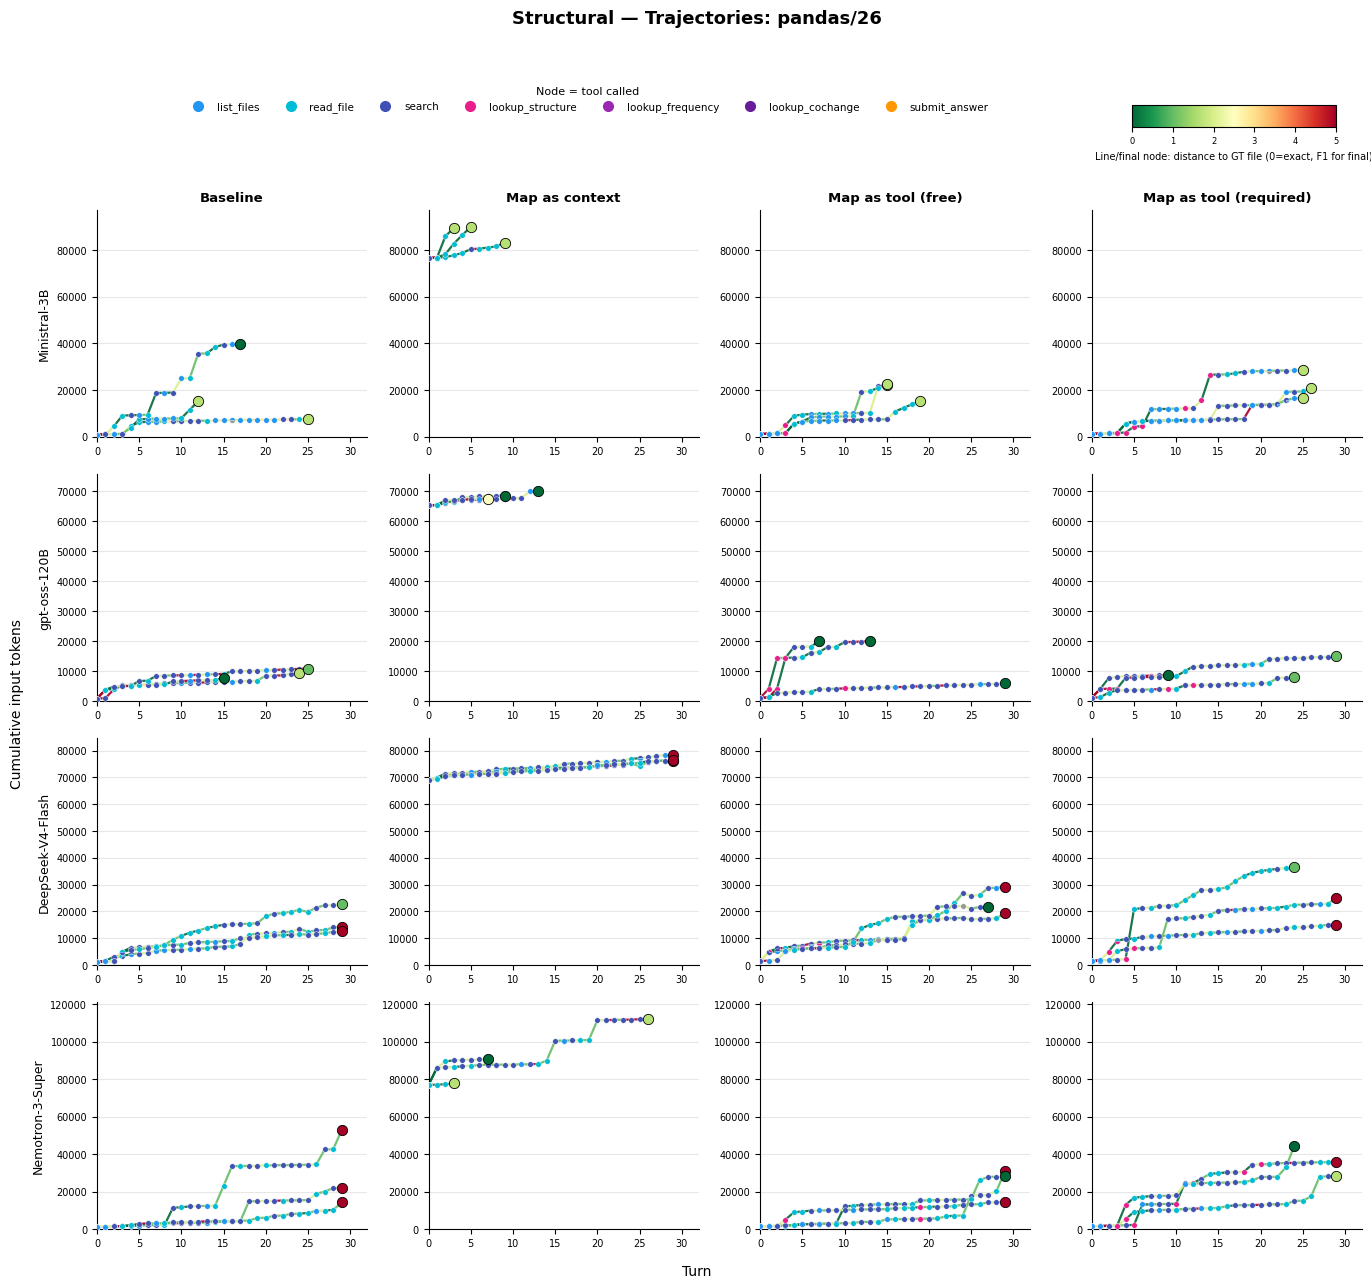

In [114]:
plot_trajectories('pandas', 26, 'Structural', align_y_per_model=True, fixed_x_axis=True,
                   show_nodes=True)

## Browse an issue

Call `show_issue(repo, issue_idx)` for any issue in `sel_df` — run the cell below as-is for a first look, then change the arguments (see `sel_df[['repo', 'issue_idx', 'title']]` above for the full list of 45) to jump to a different one.

pandas  ·  issue #26  ·  2 ground-truth file(s)  ·  tier=large
----------------------------------------------------------------------------------------------------
tz_localize should support is_dst input array
----------------------------------------------------------------------------------------------------
When storing datetimes with timezone information in mysql I split out the is_dst flag into a
separate column.  Then when reconstructing the Timestamps I am either forced to iterate through each
row and call pytz.timezone.localize on every Timestamp which is very slow or do some magic with
localizing what I can and then manually dealing with the fall transition time (note that infer_dst
won't work because there could be many rows that have transitions in them).  I would much rather
create the DatetimeIndex from the column of dates and then call tz_localize with the is_dst column.
This would then appropriately set the offset.  ``` di = DatetimeIndex(frame['DateColumn']) di =
di.tz_l

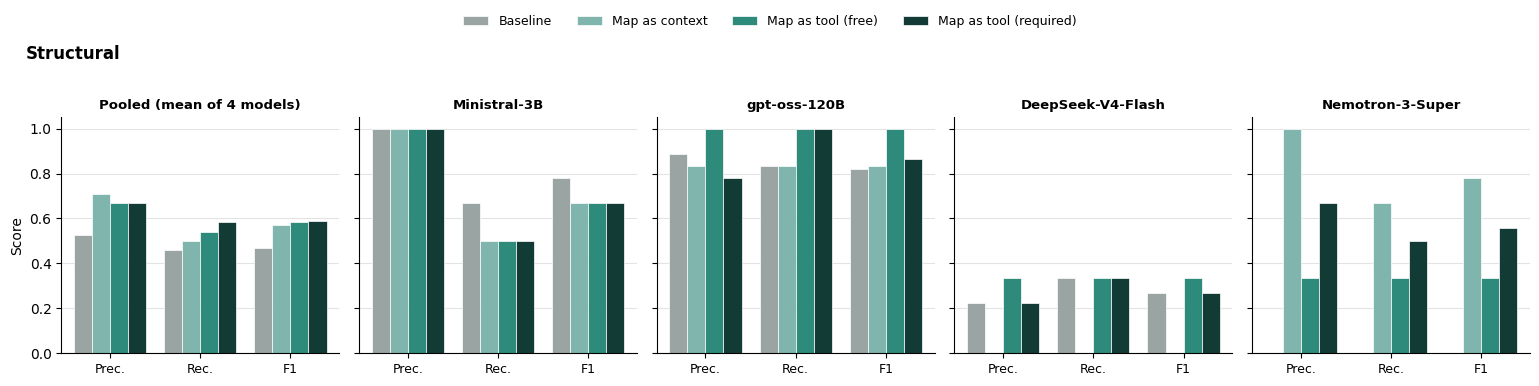

--- Structural: predictions  (ground truth: ['pandas/core/generic.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [exact ] {pandas/core/generic.py, pandas/tseries/index.py}
    Map as context        r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
    Map as tool (free)    r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
    Map as tool (required)  r1 [partial] {pandas/core/generic.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
  gpt-oss-120B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [exact ] {pandas/tseries/index.py, pandas/core/generic.py}   r3 [partial] {pandas/tseries/index.py, pandas/core/generic.py, pandas/tseries/period.py}
    Map as context        r1 [exact

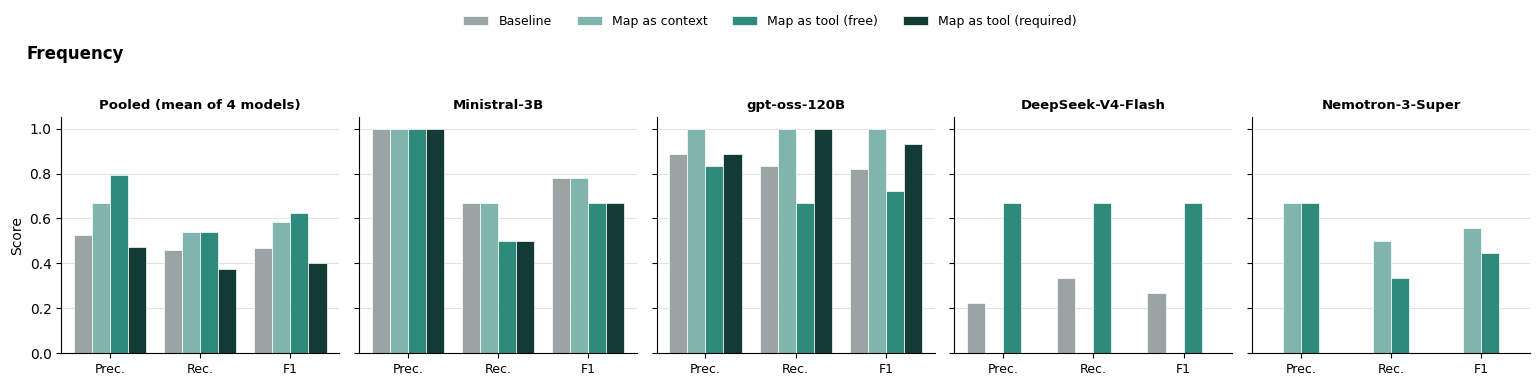

--- Frequency: predictions  (ground truth: ['pandas/core/generic.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [exact ] {pandas/core/generic.py, pandas/tseries/index.py}
    Map as context        r1 [exact ] {pandas/core/generic.py, pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/core/generic.py}
    Map as tool (free)    r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
    Map as tool (required)  r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
  gpt-oss-120B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [exact ] {pandas/tseries/index.py, pandas/core/generic.py}   r3 [partial] {pandas/tseries/index.py, pandas/core/generic.py, pandas/tseries/period.py}
    Map as co

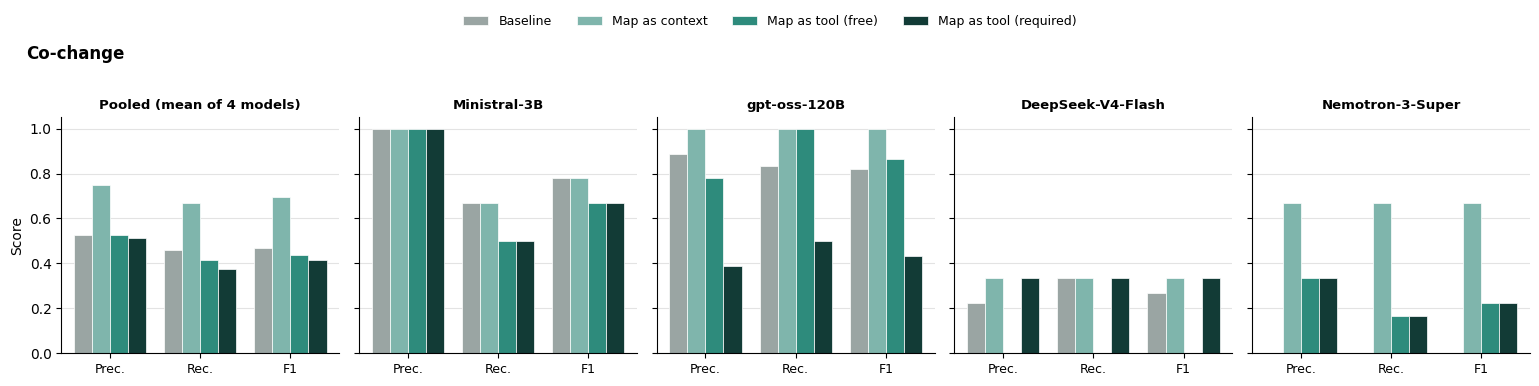

--- Co-change: predictions  (ground truth: ['pandas/core/generic.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [exact ] {pandas/core/generic.py, pandas/tseries/index.py}
    Map as context        r1 [partial] {pandas/core/generic.py}   r2 [partial] {pandas/core/generic.py}   r3 [exact ] {pandas/core/generic.py, pandas/tseries/index.py}
    Map as tool (free)    r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
    Map as tool (required)  r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
  gpt-oss-120B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [exact ] {pandas/tseries/index.py, pandas/core/generic.py}   r3 [partial] {pandas/tseries/index.py, pandas/core/generic.py, pandas/tseries/period.py}
    Map as con

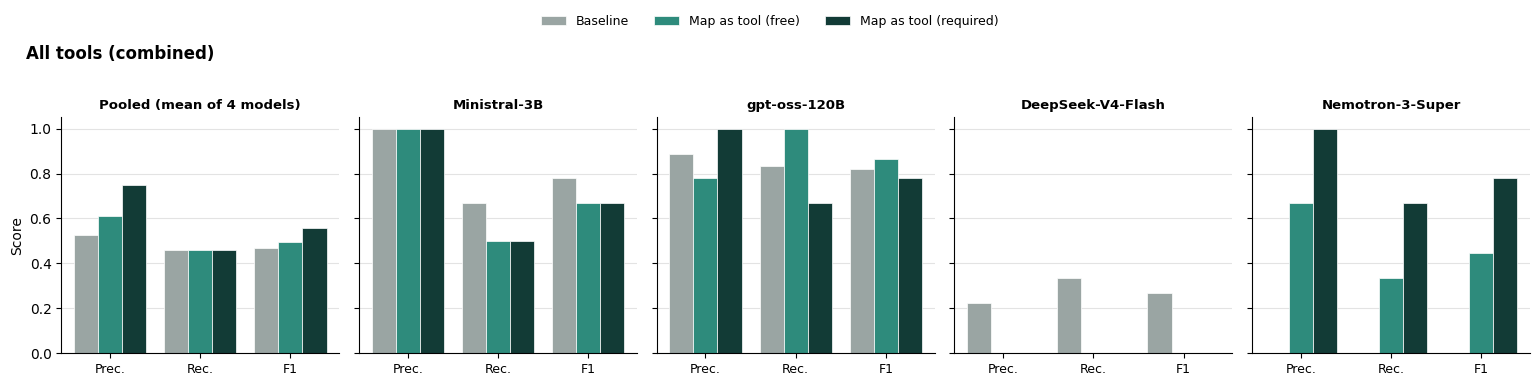

--- All tools (combined): predictions  (ground truth: ['pandas/core/generic.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [exact ] {pandas/core/generic.py, pandas/tseries/index.py}
    Map as tool (free)    r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
    Map as tool (required)  r1 [partial] {pandas/tseries/index.py}   r2 [partial] {pandas/tseries/index.py}   r3 [partial] {pandas/tseries/index.py}
  gpt-oss-120B
    Baseline              r1 [partial] {pandas/tseries/index.py}   r2 [exact ] {pandas/tseries/index.py, pandas/core/generic.py}   r3 [partial] {pandas/tseries/index.py, pandas/core/generic.py, pandas/tseries/period.py}
    Map as tool (free)    r1 [partial] {pandas/tseries/index.py, pandas/core/generic.py, pandas/tseries/period.py}   r2 [exact ] {pandas/tseries/index.py, pandas/core/gene

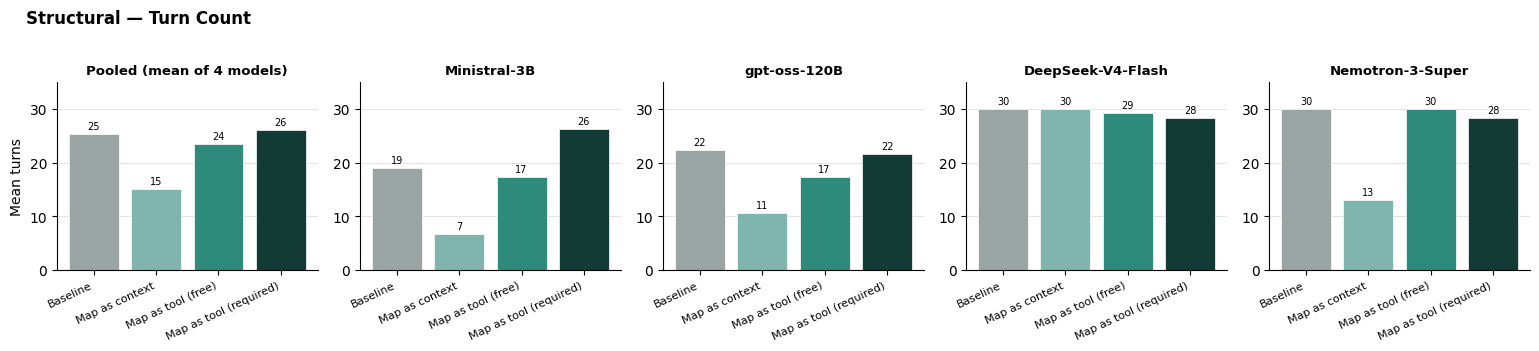

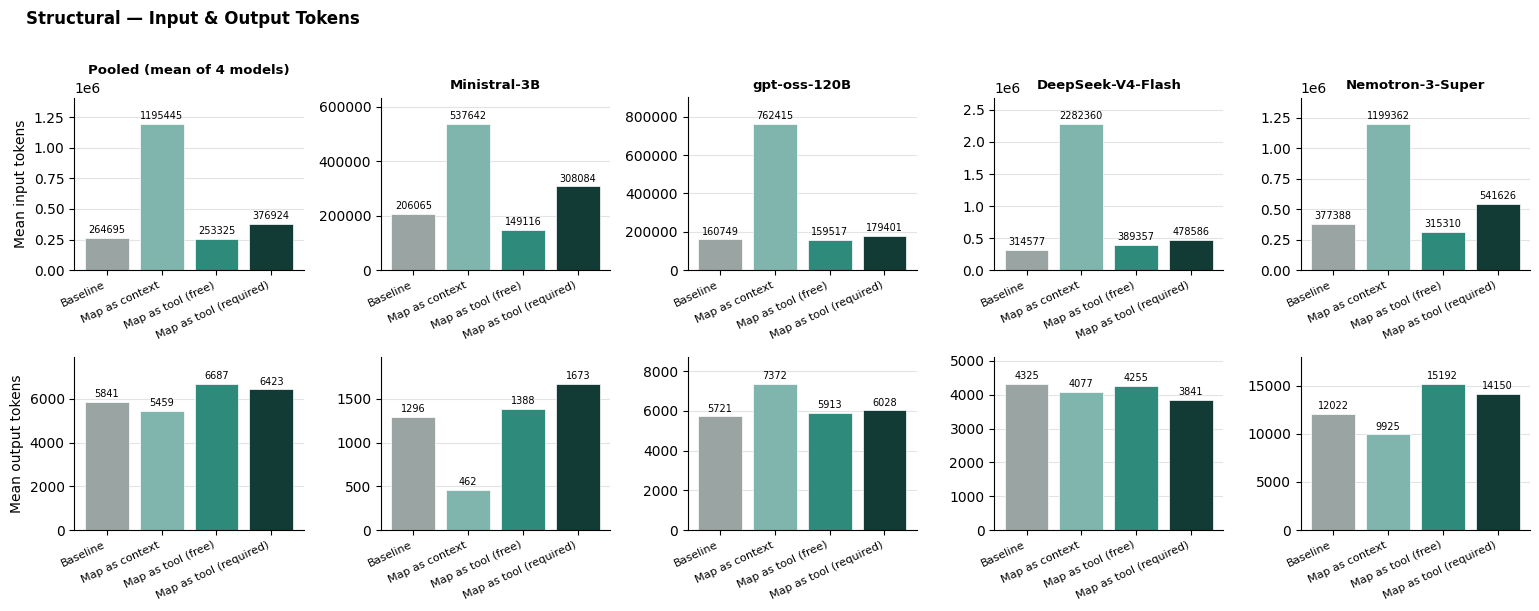

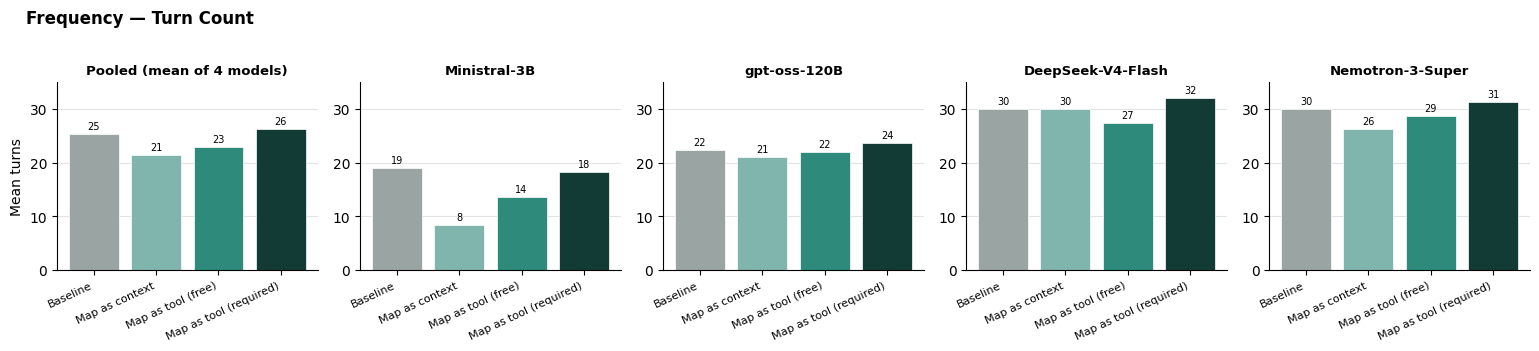

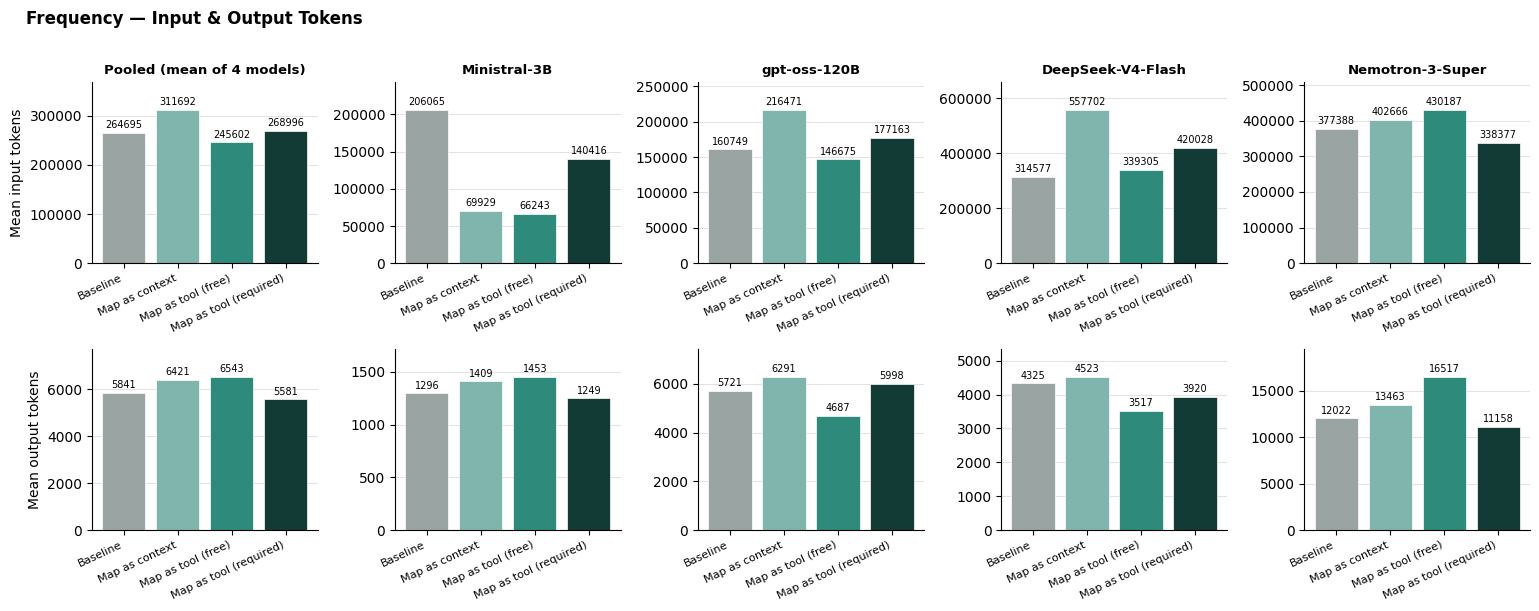

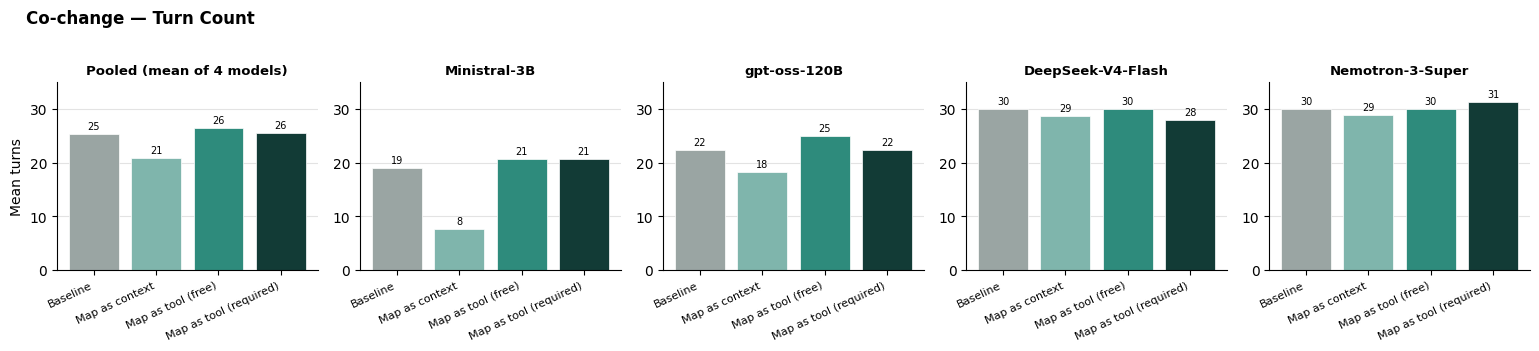

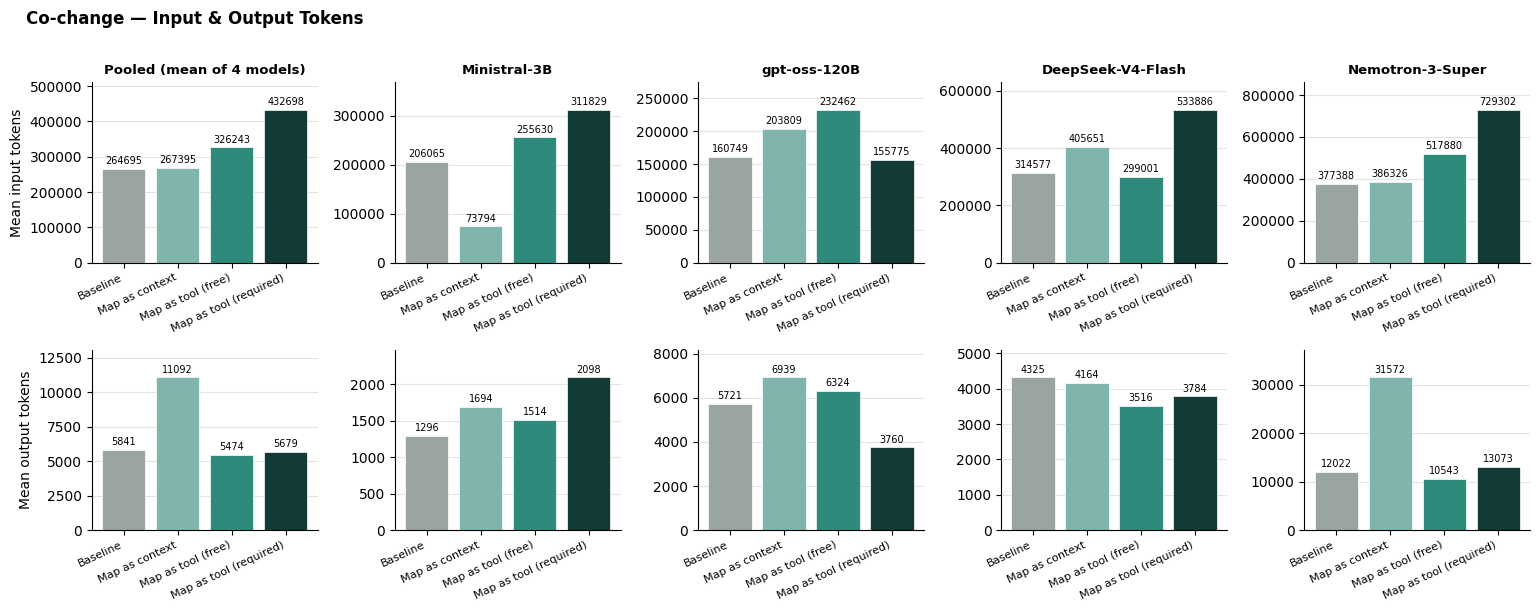

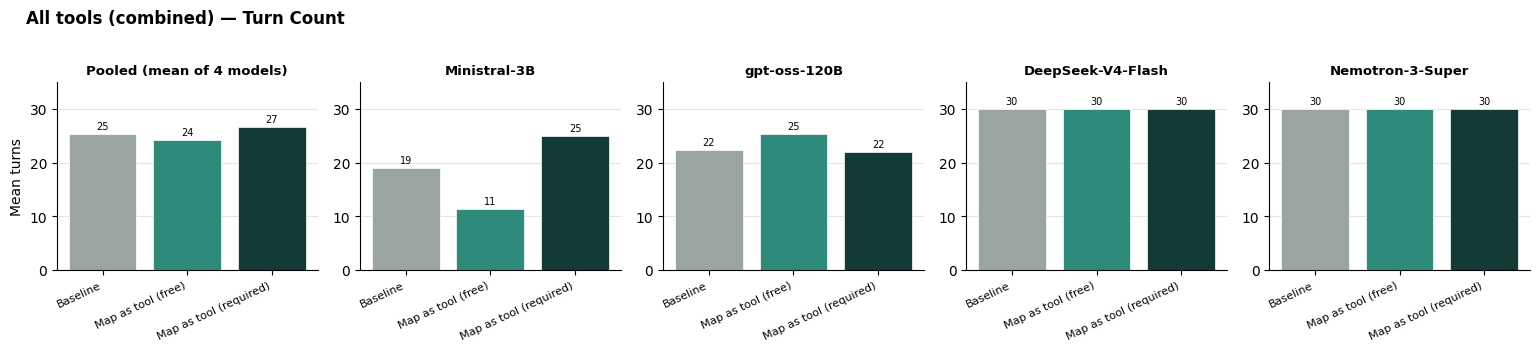

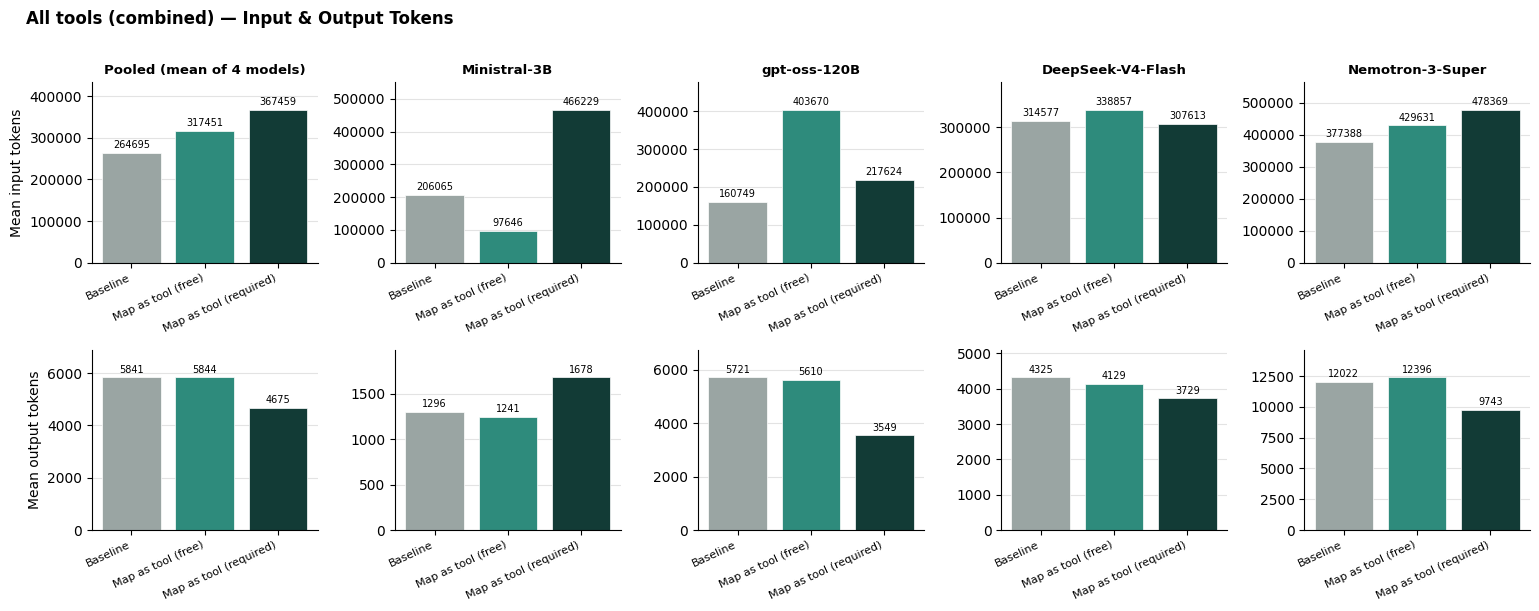

In [10]:
show_issue('pandas', 26)